# DS4DS Exercise Sheet 6

**General Instructions:**

- Review the weekly course material (lectures, readings, slides, etc.) before starting the exercises.
- Complete all assigned exercises independently before the Q&A session.
- Please use Julia Version 1.12.x to ensure compatibility.
- Please only write between the `#--- YOUR CODE STARTS HERE ---#` and `#--- YOUR CODE ENDS HERE ---#` comments.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy import optimize
import time

### Task 1: OLS for the nonlinear pendulum

We once again consider the nonlinear, frictionless pendulum that we have already seen in Exercise 02. The state-space representation of the pendulum is given by

$$
\begin{align}
    \mathbf{x}(t) = \begin{bmatrix}\theta(t)\\ \frac{\mathrm{d}\theta(t)}{\mathrm{d}t} \end{bmatrix}
\end{align}
$$

and

$$
\begin{align}
    \frac{\mathrm{d}\mathbf{x}(t)}{\mathrm{d}t} = \begin{bmatrix}x_2(t) \\ -\frac{g}{L} \sin{(x_1(t))} \end{bmatrix}
\end{align}
$$

where $g = 9.81 \frac{\mathrm{m}}{\mathrm{s}^2}$ is the magnitude of the gravitational field, $L = 1 \mathrm{m}$ is the length of the rod, $\theta$ is the angle from the vertical axis, and $\frac{\mathrm{d}\mathbf{\theta}(t)}{\mathrm{d}t}$ is the angular velocity.

In [3]:
# Model parameters defined as constants, i.e., they can be also used within function calls
g = 9.81; # gravity constant
L = 1.0; # length of pendulum

**a)** Now we want to study the system using data. To this end, implement the function `Tsit5_ode_solver` and the function `pendulum!` (which contains the right-hand side of the ODE) outlined below. Within your solution, you are to use the `Tsit5()`-ODE Solver from the `OrdinaryDiffEq`-package. The state trajectory must be specified at the times $t=0, \Delta t, 2 \cdot \Delta t \dots$.

**Hint:** Here you can find out how to use the package: https://docs.sciml.ai/DiffEqDocs/stable/.

In [4]:
# Define the ODE model shown above as a function which can be passed to a solver

def simple_pendulum(t, x):
    return np.array([x[1], -(g / L) * np.sin(x[0])])


def Tsit5_ode_solver(ode_function, x0, tspan, dt):
    """Defines the ODE problem and solves it.
    
    Args:
        ode_function: The ODE defined as a function that can be passed to the solver
        x0: Initial state of the system
        tspan: time-span in which the system should be evaluated (This is a tuple with two values (t_0, t_e))
        dt: The length of each of the timesteps
        
    Returns:
        t: A vector containing the time for the corresponding elements in the state trajectory
        x: State trajectory as a Matrix in the form (n_states, N) where N is the length of the trajectory
    """
    t0, t_e = tspan
    
    # Generate time vector based on the fixed step size dt
    t = np.arange(t0, t_e + dt, dt)
    
    # Ensure the final time step doesn't overshoot t_e
    if t[-1] > t_e:
        t[-1] = t_e
        
    N = len(t)
    x_current = np.array(x0, dtype=float)
    n_states = x_current.size
    
    # Initialize state trajectory matrix (n_states, N)
    x = np.zeros((n_states, N))
    x[:, 0] = x_current
    
    # Tsit5 Butcher Tableau Coefficients
    C = [0.0, 0.161, 0.327, 0.9, 0.9800255409045097, 1.0, 1.0]
    A = [
        [],
        [0.161],
        [-0.008480655492357, 0.3354806554923570],
        [2.897153057105494, -6.359448489975075, 4.362295432869581],
        [5.32586482843925895, -11.74888356406283, 7.495539342889836, -0.09249506636175525],
        [5.86145544294642038, -12.92096931784711, 8.159367898576159, -0.071584973281401006, -0.02826905039406838]
    ]
    B = [0.09646076681806523, 0.01, 0.4798896504144996, 1.379008574103742, -3.290069515436081, 2.324710524099774, 0.0]
    
    # Initial stage evaluation
    k1 = np.asarray(ode_function(t[0], x_current))
    
    # Integration loop
    for i in range(1, N):
        h = t[i] - t[i-1]
        t_curr = t[i-1]
        
        # Calculate intermediate stages
        k2 = np.asarray(ode_function(t_curr + C[1]*h, x_current + h * (A[1][0]*k1)))
        k3 = np.asarray(ode_function(t_curr + C[2]*h, x_current + h * (A[2][0]*k1 + A[2][1]*k2)))
        k4 = np.asarray(ode_function(t_curr + C[3]*h, x_current + h * (A[3][0]*k1 + A[3][1]*k2 + A[3][2]*k3)))
        k5 = np.asarray(ode_function(t_curr + C[4]*h, x_current + h * (A[4][0]*k1 + A[4][1]*k2 + A[4][2]*k3 + A[4][3]*k4)))
        k6 = np.asarray(ode_function(t_curr + C[5]*h, x_current + h * (A[5][0]*k1 + A[5][1]*k2 + A[5][2]*k3 + A[5][3]*k4 + A[5][4]*k5)))
        
        # Form the new state
        x_current = x_current + h * (B[0]*k1 + B[1]*k2 + B[2]*k3 + B[3]*k4 + B[4]*k5 + B[5]*k6) #B matrix assigns the weights to the different stages
        
        # Save to trajectory
        x[:, i] = x_current
        
        # First Same As Last (FSAL) property: 
        # Evaluate k7 at the new point, which becomes k1 for the next step.
        k7 = np.asarray(ode_function(t_curr + h, x_current))
        k1 = k7
        
    return t, x

**b)** Use the functions implemented above to simulate the system on the time horizon $[t_0, t_e] = [0 \mathrm{s}, 2.5 \mathrm{s}]$ with $\Delta t = 0.01 \mathrm{s}$ and create trajectory data for different initial conditions for $\mathbf{x}_0$

- i.)  $ \,\, \mathbf{x}_{0,i} = \begin{bmatrix}\frac{\pi}{9}\\ 0 \end{bmatrix}$
- ii.) $ \, \mathbf{x}_{0,ii} = \begin{bmatrix}\frac{\pi}{4}\\ 0 \end{bmatrix}$
- iii.) $ \mathbf{x}_{0,iii} = \begin{bmatrix}\frac{\pi}{2}\\ 0 \end{bmatrix}$.

Find the period $T$ with which the system oscillates for the different initial conditions. To this end, find the first point $t$ when $\theta(t) \approx \theta_0$ (take the point from your discrete trajectory that is closest to this value with regard to the 2-norm of the error). Save your results for $T$ in the variables $T_i$, $T_{ii}$ and $T_{iii}$ respectively.

In [5]:
def get_T_estimate(x0):

    ### BEGIN SOLUTION
    tspan = (0.0, 2.5)
    dt = 0.01

    # Simulate the system using the solver implemented previously
    t, x = Tsit5_ode_solver(simple_pendulum, x0, tspan, dt)

    # Calculate the 2-norm of the error for all time steps
    # x is of shape (n_states, N), so we reshape x0 to subtract properly
    x0_col = np.array(x0).reshape(-1, 1)
    errors = np.linalg.norm(x - x0_col, axis=0)

    # Find the first local minimum of the error (which represents the completion of one period)
    # We skip the very first few steps where the error is simply increasing from 0
    min_idx = 0
    for i in range(1, len(errors) - 1):
        if errors[i] < errors[i-1] and errors[i] < errors[i+1]:
            min_idx = i
            break

    # Fallback in case a local minimum isn't cleanly found (e.g., if the period is longer than t_e)
    # Just take the global minimum while ignoring the first 0.5 seconds
    if min_idx == 0:
        skip = int(0.5 / dt) 
        min_idx = skip + np.argmin(errors[skip:])

    T = t[min_idx]
    ### END SOLUTION

    return T, x

### BEGIN SOLUTION
# Define the initial condition vectors
x0_i = np.array([np.pi / 9, 0.0])
x0_ii = np.array([np.pi / 4, 0.0])
x0_iii = np.array([np.pi / 2, 0.0])

# Run the estimations and save the variables as requested
T_i, x_i = get_T_estimate(x0_i)
T_ii, x_ii = get_T_estimate(x0_ii)
T_iii, x_iii = get_T_estimate(x0_iii)
### END SOLUTION

**c)** Use the OLS approach to identify the matrix $\mathbf{\tilde{A}}$ of an approximated linear system of the form $\mathbf{x}[k+1] = \mathbf{\tilde{A}} \mathbf{x}[k]$. Use your trajectories from a) and identify one matrix per trajectory.

To identify the matrix $\tilde{\mathbf{A}}$ using Ordinary Least Squares (OLS), we want to find the best-fit linear relationship mapping the current state to the next state: $\mathbf{x}[k+1] = \tilde{\mathbf{A}}\mathbf{x}[k]$.

If we organize our trajectory data into two matrices:

1. $X_k$ containing all states from step $0$ to $N-1$
2. $X_{k+1}$ containing all states from step $1$ to $N$

The system becomes $X_{k+1} = \tilde{\mathbf{A}}X_k$. We can solve for $\tilde{\mathbf{A}}$ using the Moore-Penrose pseudoinverse ($+$):

$$\tilde{\mathbf{A}} = X_{k+1} X_k^+$$

In [6]:
def estimate_A_tilde_OLS(x):

    ### BEGIN SOLUTION
    x_k=x[:, :-1]
    x_k1=x[:, 1:]
    A_tilde=np.linalg.lstsq(x_k.T, x_k1.T, rcond=None)[0]

    ### END SOLUTION

    return A_tilde

### BEGIN SOLUTION
# Assuming x_i, x_ii, and x_iii are the trajectories saved from part a)
A_tilde_i = estimate_A_tilde_OLS(x_i)
A_tilde_ii = estimate_A_tilde_OLS(x_ii)
A_tilde_iii = estimate_A_tilde_OLS(x_iii)

# Optional: print the results to verify
print("A_tilde_i:\n", A_tilde_i)
print("A_tilde_ii:\n", A_tilde_ii)
print("A_tilde_iii:\n", A_tilde_iii)
### END SOLUTION

A_tilde_i:
 [[ 0.99951702 -0.09659007]
 [ 0.00999849  0.9995376 ]]
A_tilde_ii:
 [[ 0.99954672 -0.09065439]
 [ 0.00999889  0.99962745]]
A_tilde_iii:
 [[ 0.99965065 -0.06987101]
 [ 0.00999864  0.99960982]]


In [7]:
# Using np.outer to achieve the broadcasted multiplication
x_test = np.outer([-1, 2], [1, 2, -3, 4])
A_tilde_test = estimate_A_tilde_OLS(x_test)

**d)** Approximate the eigenfrequencies $\omega$ of the system for the three initial conditions given above using the $\mathbf{\tilde{A}}$ matrices. Then use these frequencies to approximate the oscillating periods $\tilde{T}$ of the learned linear systems.

In [8]:
def calculate_frequency(A_tilde):
    
    ### BEGIN SOLUTION
    
    # The time step used in part b)
    dt = 0.01 
    
    # Calculate the eigenvalues of the matrix A_tilde
    eigenvalues = np.linalg.eigvals(A_tilde)
    
    # Extract the angle (phase) of the first complex eigenvalue
    # np.angle returns values in the range [-pi, pi]
    angle = np.angle(eigenvalues[0])
    
    # The frequency is the absolute angle divided by the time step
    omega = np.abs(angle) / dt
    ### END SOLUTION
    
    return omega

**e)** Determine the relative error between the estimates for the oscillating periods from subtask b) and d). Consider the value from b) to be the truth. 

In [9]:
# Calculate eigenfrequencies using the matrices from part c)
omega_i = calculate_frequency(A_tilde_i)
omega_ii = calculate_frequency(A_tilde_ii)
omega_iii = calculate_frequency(A_tilde_iii)

# Calculate the oscillating periods (T = 2*pi / omega)
T_approx_i = 2 * np.pi / omega_i
T_approx_ii = 2 * np.pi / omega_ii
T_approx_iii = 2 * np.pi / omega_iii

# Optional: Print results to compare with the T values found in part b)
print(f"Approximate Period 1: {T_approx_i:.4f} s")
print(f"Approximate Period 2: {T_approx_ii:.4f} s")
print(f"Approximate Period 3: {T_approx_iii:.4f} s")

Approximate Period 1: 2.0215 s
Approximate Period 2: 2.0867 s
Approximate Period 3: 2.3768 s


**f)** Use the estimated matrices from c) to predict the system behavior for the three different initial conditions over the same timespan as before. Compute the MSE between the true trajectory and the linear approximation.

The MSE is defined as

$$
\begin{align}
    \mathrm{MSE}(\begin{bmatrix}\mathbf{x}[1] & \dots & \mathbf{x}[N]\end{bmatrix}, \begin{bmatrix}\mathbf{\tilde{x}}[1] & \dots & \mathbf{\tilde{x}}[N]\end{bmatrix}) 
    = \frac{1}{N} \sum_{k=1}^N \| \mathbf{x}[k] - \mathbf{\tilde{x}}[k] \|_2^2
\end{align}.
$$

In [10]:
### BEGIN SOLUTION
def predict_linear_trajectory(A_tilde, x0, N):
    """Simulates the linear system x[k+1] = A_tilde * x[k]"""
    n_states = len(x0)
    x_pred = np.zeros((n_states, N))
    x_pred[:, 0] = x0
    
    # Iteratively calculate the next state
    for k in range(1, N):
        x_pred[:, k] = A_tilde @ x_pred[:, k-1]
        
    return x_pred

def compute_mse(x_true, x_pred):
    """Computes the Mean Squared Error as defined in the formula"""
    N = x_true.shape[1]
    
    # np.linalg.norm with axis=0 computes the L2 norm for each time step (column)
    norms = np.linalg.norm(x_true - x_pred, axis=0)
    
    # Square the norms, sum them up, and divide by N
    mse = np.sum(norms**2) / N
    return mse

# Get the total number of time steps N (assuming all trajectories have the same length)
N = x_i.shape[1]

# 1. Predict the system behavior for the three initial conditions
x_pred_i = predict_linear_trajectory(A_tilde_i, x0_i, N)
x_pred_ii = predict_linear_trajectory(A_tilde_ii, x0_ii, N)
x_pred_iii = predict_linear_trajectory(A_tilde_iii, x0_iii, N)

# 2. Compute the MSE between the true trajectories and linear approximations
mse_i = compute_mse(x_i, x_pred_i)
mse_ii = compute_mse(x_ii, x_pred_ii)
mse_iii = compute_mse(x_iii, x_pred_iii)

# Output the results to verify
print(f"MSE for trajectory i:   {mse_i:.6e}")
print(f"MSE for trajectory ii:  {mse_ii:.6e}")
print(f"MSE for trajectory iii: {mse_iii:.6e}")
### END SOLUTION

MSE for trajectory i:   7.100670e-01
MSE for trajectory ii:  3.328166e+00
MSE for trajectory iii: 1.103729e+01


## 2) DMD of the flow past a cylinder

Perform a DMD analysis on the vortex shedding data set. This phenomenon occurs frequently in nature, when a fluid hits a bluff body (see, e.g., the following NASA video on cloud patterns: https://www.youtube.com/watch?v=SawKLWT1bDA). The data set consists of 50 snapshots (with $\Delta t = 0.1$) of the absolute velocity of a fluid entering from the left and flowing around a cylinder. Each snapshot contains velocity measurements on a $449 x 199$ grid. In vectorized form, this leads to a data matrix $Z \in \mathbb{R}^{89351 \times 151}$.

In [11]:
# load the data
import scipy

data = scipy.io.loadmat("VortexShedding.mat")
data = data["Z"];

You may use this code to produce an example plot of the initial state:
```
display(heatmap(reshape(data[:, 1], 199, 449), aspect_ratio=1, color=:auto, title="Initial state"))
```
<img src="./initial_state.png" alt="initial_state" width="800"/>

Additionally, if you want to take a closer look at the data, there is an animation of the data as a gif in the exercise folder.

### The Concept: Dynamic Mode Decomposition (DMD) and SVD

**Dynamic Mode Decomposition (DMD)** is a powerful, data-driven technique used to discover the underlying linear dynamics of a complex, non-linear system (like fluid flowing past a cylinder). It attempts to find a best-fit linear operator $A$ that maps the current state of the system to the next state:


$$x_{k+1} = A x_k$$

To find this operator, we first arrange our sequence of data snapshots into two time-shifted matrices:

* **$Z$**: Contains all snapshots from time $t_0$ to $t_{N-1}$ (the "current" states).
* **$Z'$**: Contains all snapshots from time $t_1$ to $t_N$ (the "next" states).

This allows us to write the relationship for the entire dataset as $Z' = A Z$.

**Singular Value Decomposition (SVD)**
Because our data matrix $Z$ is extremely high-dimensional (89,351 rows representing grid pixels), computing $A$ directly is computationally impossible. Instead, we use SVD to break $Z$ down into its fundamental components:


$$Z = U \Sigma V^*$$

* **$U$**: Contains the spatial modes (patterns in the fluid flow).
* **$\Sigma$ (or $S$)**: A diagonal matrix of singular values, representing the energy or importance of each mode.
* **$V^*$**: Contains the temporal dynamics of those modes.

By performing SVD on $Z$, we can truncate the data to only the modes with the largest singular values (the most dominant patterns), drastically reducing the dimensionality of the problem before solving for the system dynamics in later steps.

### Task a)
Decompose the data matrix into the two time-shifted versions $Z$ and $Z’$ and compute a singular value decomposition of $Z$. Store the 10 largest singular values $\sigma$ in a separate array.

**Hint: Use the parameters created here in the course of further tasks instead of executing SVD again.**

In [12]:
### BEGIN SOLUTION
from scipy.linalg import svd

# 1. Decompose the data matrix into time-shifted versions
# Z contains all columns except the last
Z = data[:, :-1]

# Z' (Z_prime) contains all columns except the first
Z_prime = data[:, 1:]

# 2. Compute the Singular Value Decomposition of Z
# We use full_matrices=False to perform an economy SVD (crucial for tall matrices)
U, S, Vt = svd(Z, full_matrices=False)

# 3. Store the 10 largest singular values in a separate array
# scipy's svd automatically returns S in descending order
sigma = S[:10]
    
### END SOLUTION

### Task b) 
How many singular vectors are at least required to reconstruct 1) 90% and 2) 99% of the original information? (_Hint: Take a look at the singular values_)

### The Concept: Information and Singular Values

In Singular Value Decomposition (SVD), the singular values ($\sigma$) are sorted in descending order and represent the "importance" or "weight" of their corresponding singular vectors (modes).

To quantify how much "information" (often called variance or modal energy) a subset of vectors retains, we look at the singular values. Mathematically, the energy captured by a specific mode is proportional to the **square** of its singular value ($\sigma_i^2$).

To find out how many vectors $k$ are needed to capture a certain percentage of the total information, we calculate the cumulative sum of the squared singular values and divide it by the total sum of all squared singular values:


$$\text{Information Retained}(k) = \frac{\sum_{i=1}^{k} \sigma_i^2}{\sum_{i=1}^{n} \sigma_i^2}$$

In [13]:
### BEGIN SOLUTION

# 1. Calculate the total "energy" (information) in the system
# We square the singular values to represent variance/energy
total_energy = np.sum(S**2)

# 2. Calculate the cumulative energy ratio for 1, 2, 3... k vectors
cumulative_energy = np.cumsum(S**2) / total_energy

# 3. Find the first index where the cumulative energy hits our thresholds
# np.argmax returns the first index where the condition evaluates to True.
# We add 1 because arrays are 0-indexed, but we want the physical count of vectors.
req_90 = np.argmax(cumulative_energy >= 0.90) + 1
req_99 = np.argmax(cumulative_energy >= 0.99) + 1

print(f"Singular vectors required to reconstruct 90% of information: {req_90}")
print(f"Singular vectors required to reconstruct 99% of information: {req_99}")
### END SOLUTION

Singular vectors required to reconstruct 90% of information: 1
Singular vectors required to reconstruct 99% of information: 3


### Task c) 
Identify a linear model with system matrix $\tilde{A}$ from the data via dynamic mode decomposition. Set the rank of the reduced DMD method to $r=20$. Store your sulution in `tilde_A`

In Dynamic Mode Decomposition, we want to find the operator that steps the system forward in time. As discussed previously, computing the full matrix $A$ for tens of thousands of pixels is computationally prohibitive.

Instead, we project the dynamics onto a low-dimensional subspace spanned by the most important spatial patterns (the first $r$ columns of our SVD matrix $U$). This gives us a much smaller $r \times r$ matrix, denoted as $\tilde{A}$ (or $\Phi$).

The formula to calculate this reduced matrix is:


$$\tilde{A} = U_r^T Z' V_r \Sigma_r^{-1}$$

This $\tilde{A}$ matrix perfectly captures the time-evolution of the dominant features of the fluid flow, drastically reducing the math from an $89,351 \times 89,351$ problem to a $20 \times 20$ problem.

In [15]:
### BEGIN SOLUTION
r = 20

# 1. Truncate the SVD matrices to rank r=20
Ur = U[:, :r]
Sr = S[:r]
Vr = Vt[:r, :].T

# 2. Create the inverse of the truncated singular value matrix
Sigma_inv = np.diag(1.0 / Sr)

# 3. Calculate the reduced system matrix tilde_A
tilde_A = Ur.T @ Z_prime @ Vr @ Sigma_inv
### END SOLUTION

### Task d) 
Sort the eigenvalues of $\tilde{A}$ according to their frequency in ascending order (starting with 0). Which is the lowest frequency $\omega$ in the system dynamics (aside from the stationary mode with $\lambda = 0$)? In addition, calculate the corresponding period $T$ with which the system oscillates.

The matrix $\tilde{A}$ contains the "DNA" of the fluid's dynamics. By calculating its eigenvalues, we can extract the specific frequencies at which the fluid oscillates (vortex shedding).

1. **Discrete vs. Continuous:** Because our data consists of snapshots taken at discrete time intervals ($\Delta t = 0.1$), the eigenvalues of $\tilde{A}$ are discrete-time eigenvalues ($\lambda$).
2. **Extracting Frequency:** To find the physical continuous-time angular frequency ($\omega$), we look at the complex phase (angle) of the discrete eigenvalue and divide it by the time step:

$$\omega = \frac{|\text{angle}(\lambda)|}{\Delta t}$$


3. **The Stationary Mode:** A fluid flow typically has a "mean" background flow that doesn't oscillate or decay. *Note: There is likely a slight typo in the assignment—a stationary mode in discrete time actually has $\lambda = 1$, which corresponds to a continuous eigenvalue of $0$ and a frequency of $\omega = 0$.*
4. **The Period:** Once we find the lowest non-zero frequency, the time it takes for one full vortex shedding cycle (the period $T$) is simply $T = \frac{2\pi}{\omega}$.

In [16]:
### BEGIN SOLUTION
dt = 0.1  # From the dataset description

# 1. Calculate the eigenvalues of the reduced matrix
eigenvalues = np.linalg.eigvals(tilde_A)

# 2. Calculate the angular frequencies (omega) for each eigenvalue
omegas = np.abs(np.angle(eigenvalues)) / dt

# 3. Sort the eigenvalues and frequencies in ascending order
# np.argsort gives us the indices that would sort the array
sort_indices = np.argsort(omegas)
sorted_eigenvalues = eigenvalues[sort_indices]
sorted_omegas = omegas[sort_indices]

# 4. Identify the lowest non-zero frequency
# Index 0 will be the stationary mode (~0 frequency). 
# Because complex eigenvalues come in conjugate pairs, indices 1 and 2 
# will represent the fundamental vortex shedding frequency.
lowest_omega = sorted_omegas[1]

# 5. Calculate the corresponding period
T = 2 * np.pi / lowest_omega

print(f"Lowest non-zero frequency (omega): {lowest_omega:.4f} rad/s")
print(f"Corresponding period (T): {T:.4f} s")
### END SOLUTION

Lowest non-zero frequency (omega): 2.0784 rad/s
Corresponding period (T): 3.0230 s


### Task e)
Use the reduced model for prediction via the “project-map-lift” approach. To this end:
1. Project the initial state onto the $r$-dimensional subspace,
2. Simulate the low-dimensional system for 20 time steps,
3. Lift the final state last state to the original space,
4. Calculate the error (using the 2-norm) between the the reduced order model solution and the original data at that time step.

### The Concept: Project-Map-Lift

The **"Project-Map-Lift"** approach is the core workflow of Model Order Reduction (MOR). Instead of running heavy simulations on massive, high-dimensional data (like your 89,351-pixel grid), we translate the problem into a smaller space, solve it there, and translate it back.

1. **Project ($U_r^T x$):** We take our massive initial state ($t=0$) and project it onto our $r$ dominant spatial modes. Because $U_r$ is an orthogonal basis, multiplying by its transpose $U_r^T$ acts as a compression filter. It converts our 89,351-pixel image into a tiny vector of just $r=20$ weights (representing how much of each spatial mode is present).
2. **Map ($\tilde{A} \tilde{x}$):** We use our reduced dynamics matrix $\tilde{A}$ (from Task c) to step these 20 weights forward in time. Multiplying a $20 \times 20$ matrix is computationally trivial compared to an $89351 \times 89351$ matrix. We repeat this 20 times to simulate 20 time steps.
3. **Lift ($U_r \tilde{x}$):** Once we have our predicted weights at $t=20$, we multiply them back against our spatial modes $U_r$. This "lifts" the data out of the compressed space, rebuilding the full 89,351-pixel predicted snapshot.
4. **Error:** Because we threw away the smaller singular values (modes $21$ and above) when creating our reduced model, our prediction won't be 100% perfect. We calculate the $L_2$-norm of the difference between our lifted prediction and the actual 20th snapshot in the dataset to quantify the approximation error.

In [17]:
### BEGIN SOLUTION
    
# 1. Project the initial state onto the r-dimensional subspace
# The initial state is the first column of the original data matrix
x0 = data[:, 0]
x_tilde = Ur.T @ x0

# 2. Simulate the low-dimensional system for 20 time steps
# We iteratively apply the reduced dynamics matrix tilde_A
for _ in range(20):
    x_tilde = tilde_A @ x_tilde
    
# 3. Lift the final state back to the original space
x_pred = Ur @ x_tilde

# 4. Calculate the error (using the 2-norm) between the reduced model 
# solution and the original data at that time step.
# Time step 20 corresponds to index 20 in the original dataset.
x_true = data[:, 20]
error = np.linalg.norm(x_pred - x_true, ord=2)

# Optional: Print the error to see the result
print(f"2-norm error after 20 time steps: {error:.4f}")
### END SOLUTION

2-norm error after 20 time steps: 0.1958


### 1. What does the "Error" represent?

In Task (e), you used the "Project-Map-Lift" method to predict what the fluid would look like at time step 20 using only a tiny $20 \times 20$ matrix. You then compared your prediction to the *actual* observed data at time step 20.

Because your reduced model threw away a lot of information (all the singular vectors from 21 to 89,351), your prediction was not 100% perfect. The "error" is the mathematical difference between your prediction and reality.

### 2. What is a "2-norm"?

The 2-norm (also called the Euclidean norm) is a way of measuring the "total distance" between two things.

To get this number, the code essentially did this:

1. It looked at every single one of the 89,351 pixels on the grid.
2. It calculated the difference between the *true* velocity and your *predicted* velocity for each pixel.
3. It squared all those differences, added them all together, and took the square root.

So, 0.1958 is the aggregate "distance" between your predicted 89,351-pixel image and the true 89,351-pixel image.

### 3. Is 0.1958 a "good" or "bad" number?

To know if an error is good or bad, you have to look at the scale of the original data.

If you look back at the heatmap from your assignment, the fluid velocities range from about **0.0 to 1.3**.

* If your 2-norm error was something like 50.0, it would mean your prediction was complete garbage—totally disconnected from reality.
* An error of **0.1958** across tens of thousands of data points is actually quite small.

**The big takeaway:** It means your Dynamic Mode Decomposition (DMD) was highly successful. By tracking just 20 variables instead of 89,351, you were able to accurately simulate 20 time steps of complex fluid dynamics with only a tiny, acceptable margin of error.

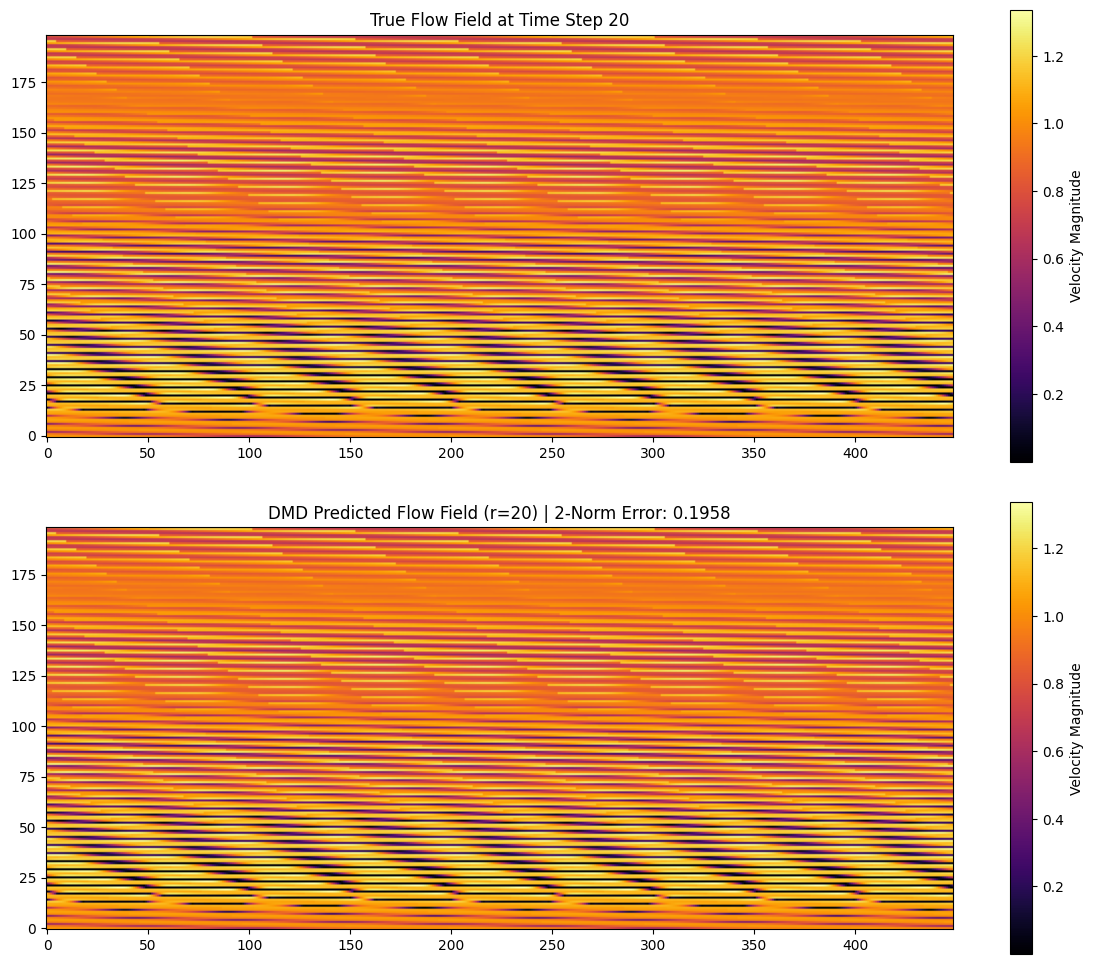

In [18]:
import matplotlib.pyplot as plt

# 1. Reshape both the true state and your prediction back to the 2D grid
# The original dimensions specified are 199 rows by 449 columns
grid_rows = 199
grid_cols = 449

# x_true and x_pred are from your previous Task e) code
true_image = x_true.reshape(grid_rows, grid_cols)
pred_image = x_pred.reshape(grid_rows, grid_cols)

# 2. Set up a side-by-side subplot figure
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot the True State
im1 = axes[0].imshow(true_image, cmap='inferno', origin='lower')
axes[0].set_title("True Flow Field at Time Step 20")
axes[0].set_aspect('equal')
fig.colorbar(im1, ax=axes[0], label='Velocity Magnitude')

# Plot the Reduced Order Model Prediction
im2 = axes[1].imshow(pred_image, cmap='inferno', origin='lower')
axes[1].set_title(f"DMD Predicted Flow Field (r=20) | 2-Norm Error: {error:.4f}")
axes[1].set_aspect('equal')
fig.colorbar(im2, ax=axes[1], label='Velocity Magnitude')

plt.tight_layout()
plt.show()